<div style="border-radius:10px; padding: 15px; box-sizing: border-box; background-color: #eaeaea; font-size:100%; text-align:left">

<h2 align="left"><font color=#ff6200>Problem:</font></h2>

In this project, we delve deep into the __diabetes problem__ in America by analyzing a health-related telephone survey, The Behavioral Risk Factor Surveillance System (BRFSS),  that is collected annually by the CDC for the year 2015 [source](https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system). This original dataset contains responses from __441,455 individuals__ and has 330 features, but based on diabetes disease research regarding factors influencing diabetes disease and other chronic health conditions, only select features are included in this analysis. Our primary objective is explore some of the following research questions:
1.	Can survey questions from the BRFSS provide __accurate predictions__ of whether an individual has diabetes?
2.	What __risk factors__ are most predictive of diabetes risk?
3.	Can we use a __subset__ of the risk factors to accurately predict whether an individual has diabetes?
4.	Can we create a short form of questions from the BRFSS using feature selection to accurately predict if someone might have diabetes or is at high risk of diabetes?

**About the Data**

| Variable | Description | Values / Range |
| :--- | :--- | :--- |
| **Diabetes_012** | Diabetes status | 0 = no diabetes or only during pregnancy, 1 = pre-diabetes or borderline diabetes, 2 = yes diabetes |
| **HighBP** | Told they have high blood pressure | 0 = No, 1 = Yes |
| **HighChol** | Ever told blood cholesterol is high | 0 = No, 1 = Yes |
| **CholCheck** | Cholesterol check within past five years | 0 = No, 1 = Yes |
| **BMI** | Body Mass Index | Numerical Value |
| **Smoker** | Smoked at least 100 cigarettes in life | 0 = No, 1 = Yes |
| **Stroke** | Ever told they had a stroke | 0 = No, 1 = Yes |
| **HeartDiseaseorAttack** | Coronary heart disease or myocardial infarction | 0 = No, 1 = Yes |
| **PhysActivity** | Physical activity in past 30 days (non-job) | 0 = No, 1 = Yes |
| **Fruits** | Consume Fruit 1+ times per day | 0 = No, 1 = Yes |
| **Veggies** | Consume Vegetables 1+ times per day | 0 = No, 1 = Yes |
| **HvyAlcoholConsump** | Heavy drinkers (M >14/wk, F >7/wk) | 0 = No, 1 = Yes |
| **AnyHealthcare** | Has health care coverage | 0 = No, 1 = Yes |
| **NoDocbcCost** | Could not see doctor due to cost | 0 = No, 1 = Yes |
| **GenHlth** | General health rating | 1 ~ 5 |
| **MentHlth** | Days of poor mental health (past 30 days) | 0 ~ 30 |
| **PhysHlth** | Days of poor physical health (past 30 days) | 0 ~ 30 |
| **DiffWalk** | Serious difficulty walking or climbing stairs | 0 = No, 1 = Yes |
| **Sex** | Sex of respondent | 0 = Female, 1 = Male |
| **Age** | Fourteen-level age category | 1 ~ 14 |
| **Education** | Highest grade or year of school completed | 1 (None) ~ 6 (College 4+ yrs) |
| **Income** | Annual household income | 1 (<$10k) ~ 8 (>$75k) |


### Import library ###

In [104]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import os
import math
import datetime
from tabulate import tabulate
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE 
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import chi2
import shap

**Import data**

In [ ]:
dirpath = r'C:\Diabetes\BRFSS2015'
os.chdir(dirpath)
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')


## Data Overview ##

In [37]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

**Convert data format to integer**

In [39]:
df = df.astype(int)

**Check for null and duplicates**

In [40]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [41]:
df[df.duplicated()].sum()

Diabetes_012               500
HighBP                    4407
HighChol                  6083
CholCheck                23727
BMI                     608616
Smoker                    5423
Stroke                       8
HeartDiseaseorAttack       176
PhysActivity             23409
Fruits                   20050
Veggies                  23208
HvyAlcoholConsump          306
AnyHealthcare            23873
NoDocbcCost                 28
GenHlth                  39395
MentHlth                  2445
PhysHlth                  1864
DiffWalk                    49
Sex                      10779
Age                     179445
Education               136754
Income                  182249
dtype: int64

**check for outlier for non-binary features ** 

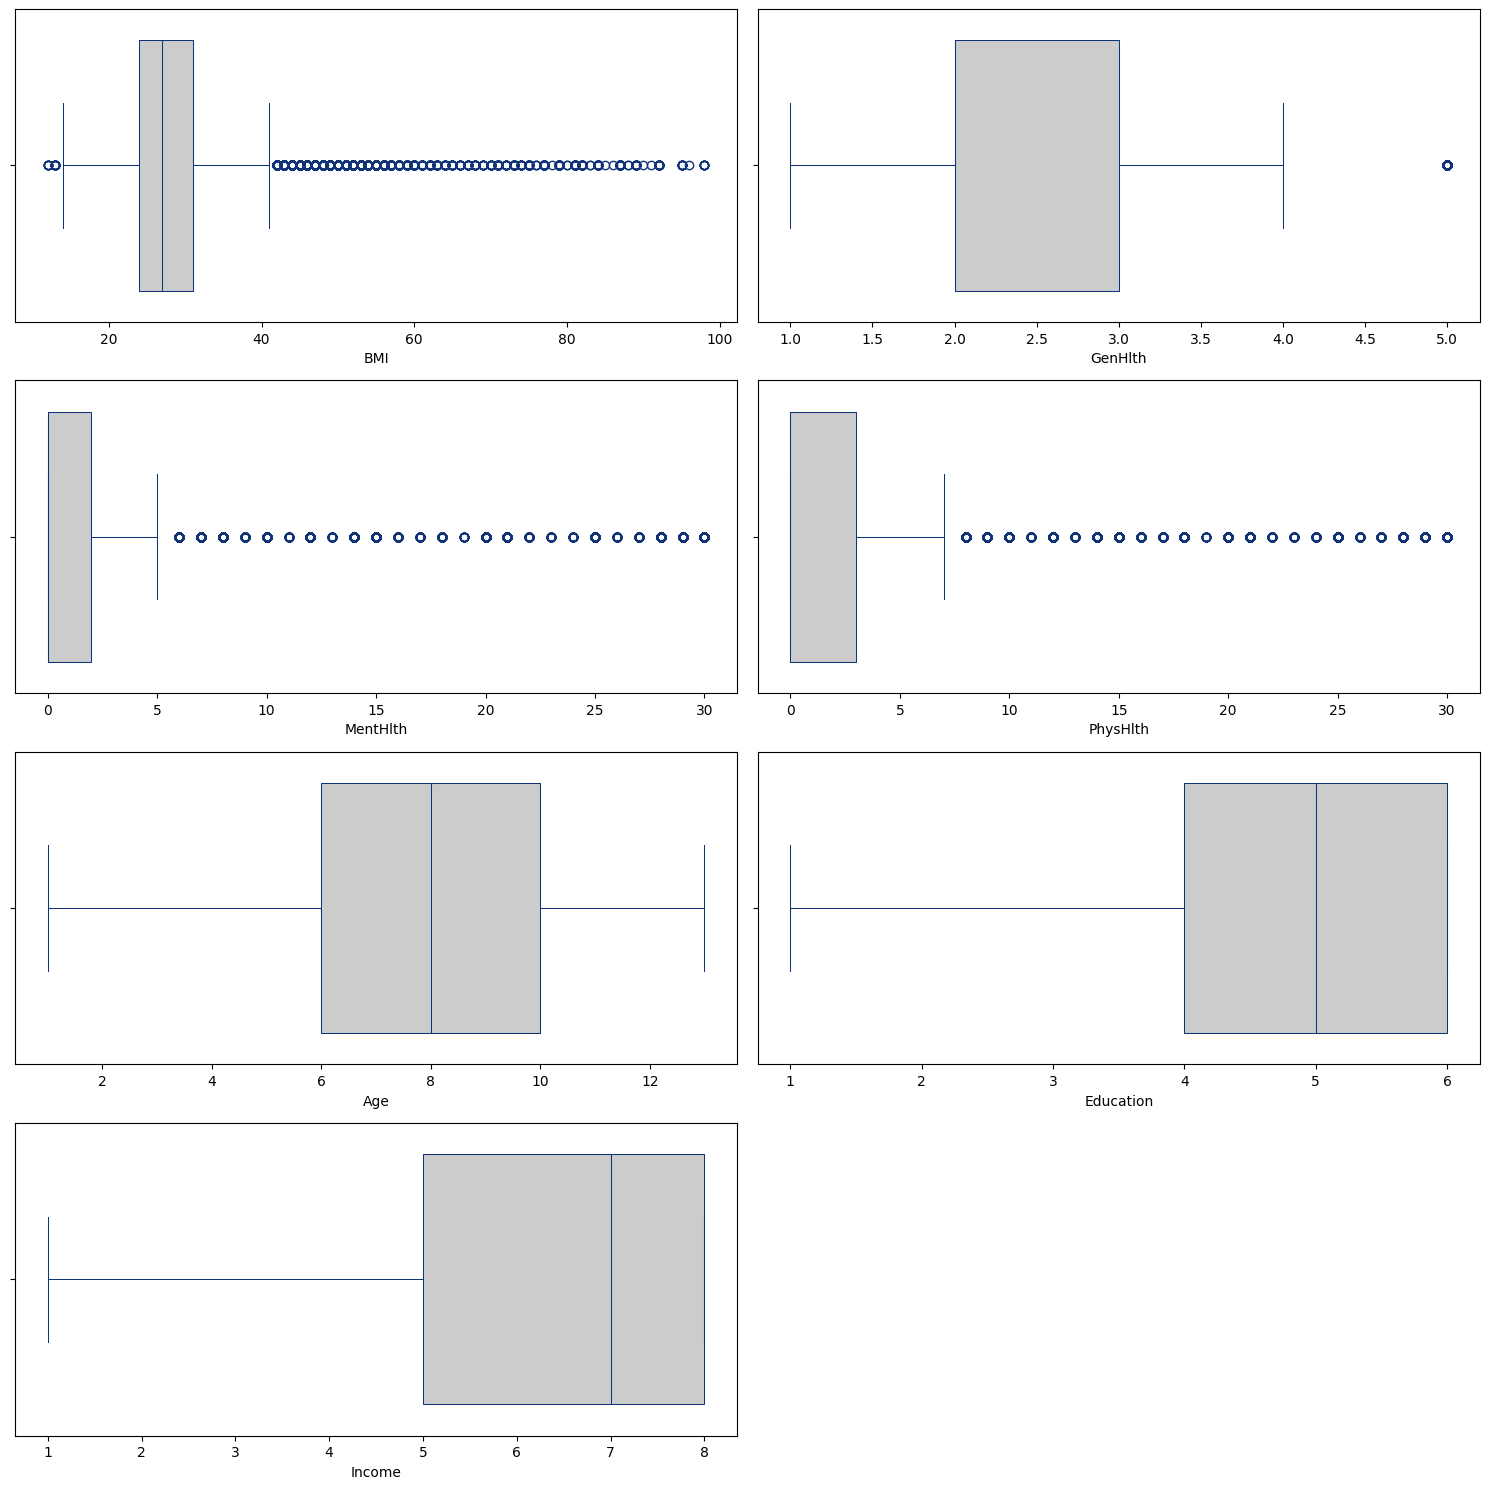

In [42]:

plt.figure(figsize = (15,15))
for i,col in enumerate( df.columns[df.nunique() > 3].tolist() ):
    plt.subplot(4,2,i+1)
    sns.boxplot(x = col, data = df, color=".8", linecolor="#137", linewidth=.75)
plt.tight_layout()
plt.show()

**Check all features distribution**

array([[<Axes: title={'center': 'Diabetes_012'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title={'c

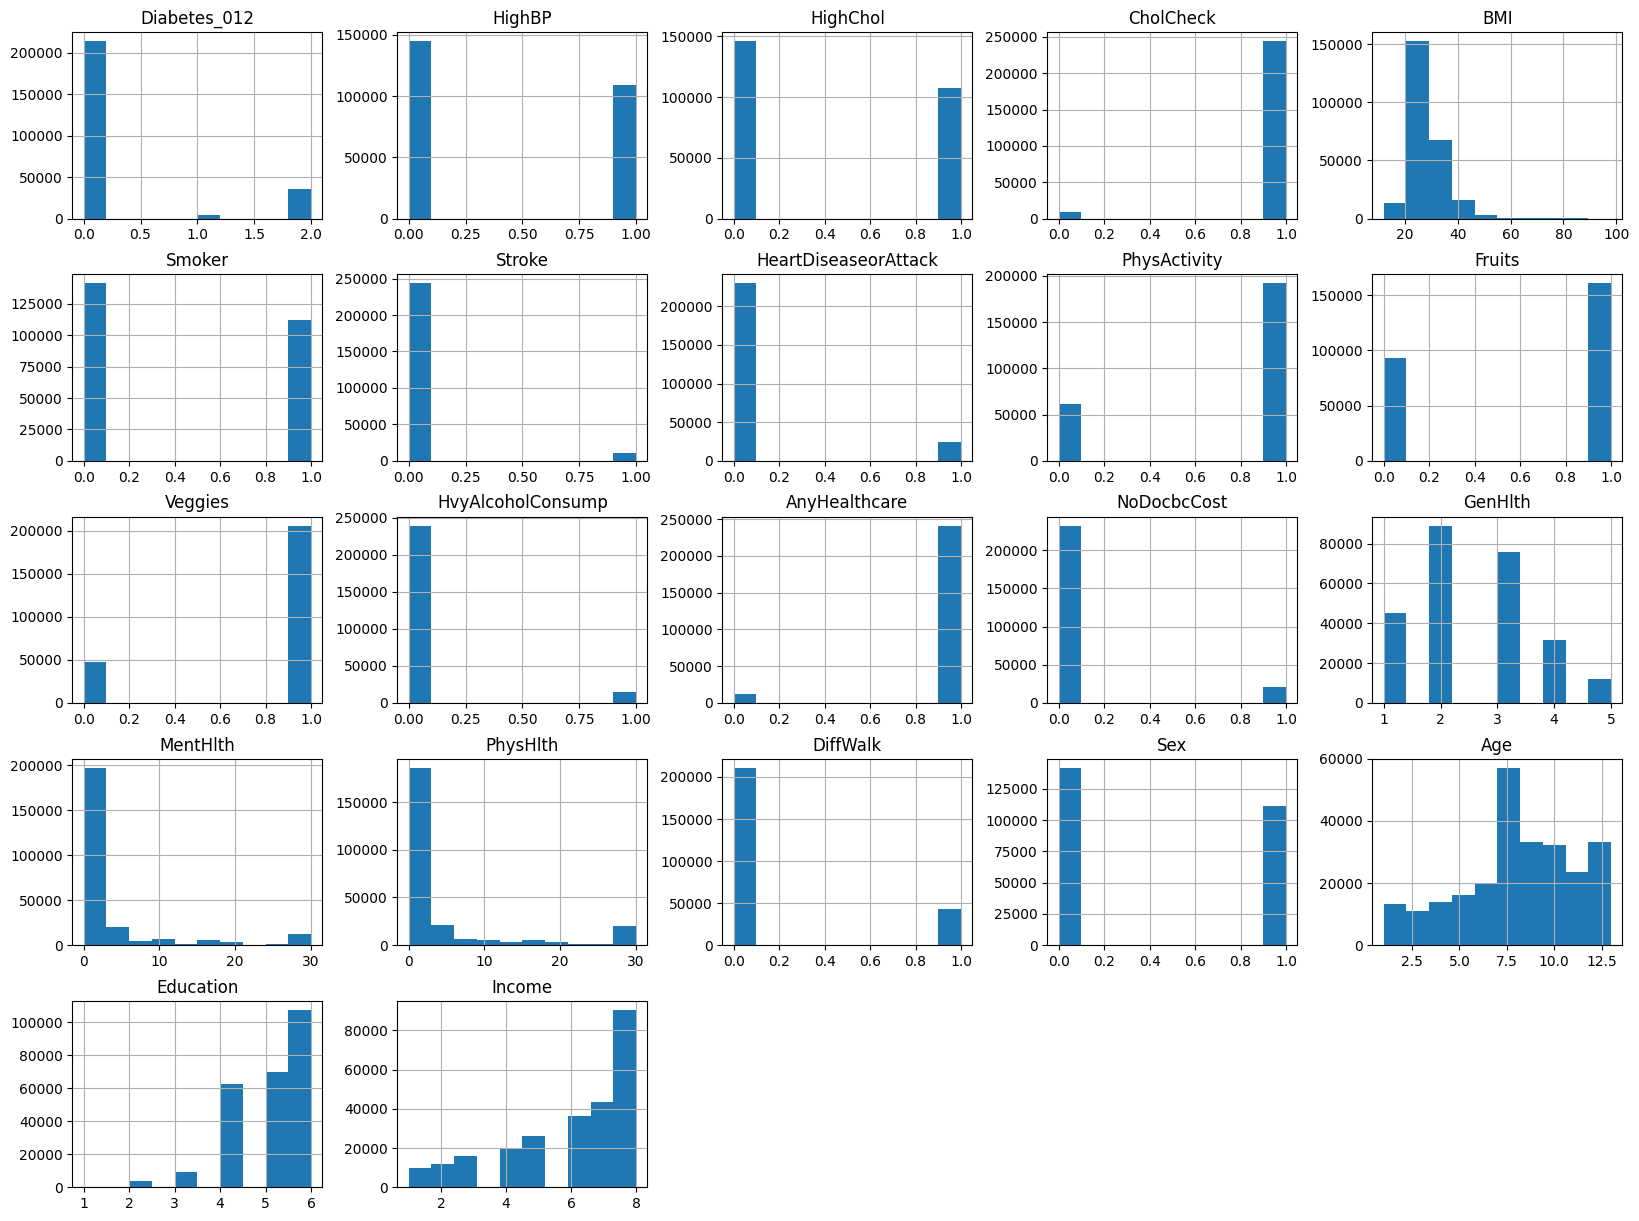

In [43]:
df.hist(figsize=(20,15))

Text(0.5, 1.0, 'correlation of feature')

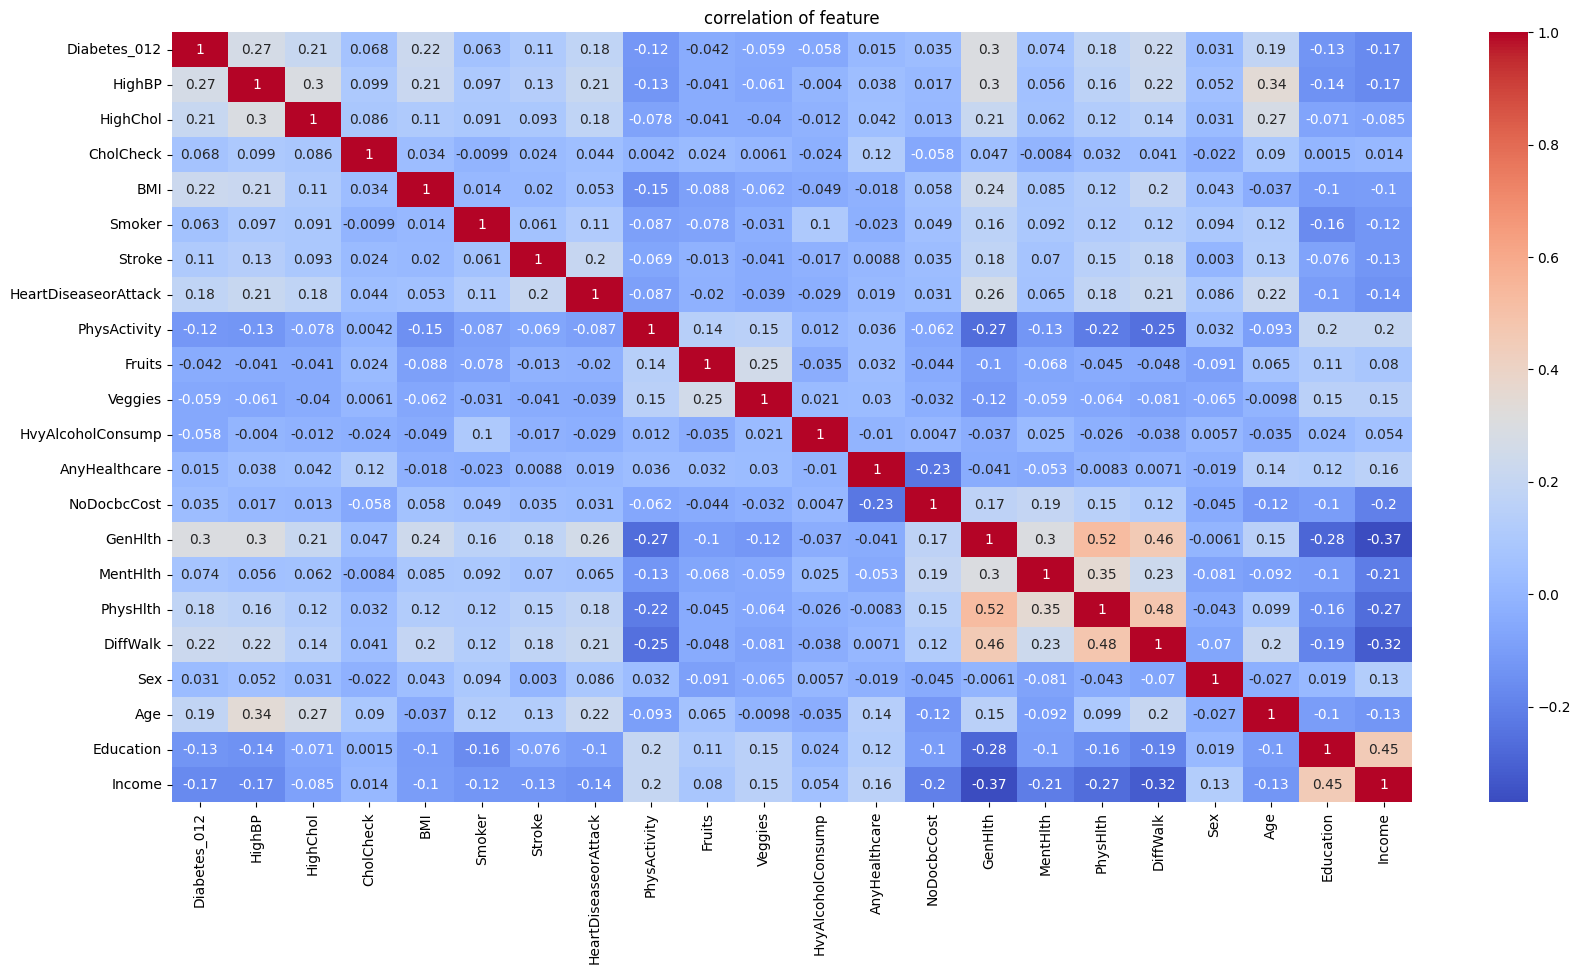

In [44]:
# check for correlation

plt.figure(figsize = (20,10))
sns.heatmap(df.corr(),annot=True, cmap= 'coolwarm' )
plt.title("correlation of feature")

### Data Label ###

In [45]:
# compute target columns distinct value distribution
df['Diabetes_012'].value_counts(normalize=True).mul(100).round(1)

Diabetes_012
0    84.2
2    13.9
1     1.8
Name: proportion, dtype: float64

**Comment**: Given pre-diabetes cases have relatively small percentage,  lets assume these cases are diabetes cases

In [46]:
# replace all 2 by 1 
df['Diabetes_012']=df['Diabetes_012'].replace(2, 1)

# rename target column 
df = df.rename(columns={'Diabetes_012': 'Diabetes_01'})


**Assign proper label to each feature**

In [47]:
label_mapping = {
    "Diabetes_01": {
        0: "No Diabetes",
        1: "Diabetes"
    },
    "HighBP": {0: "No High BP", 1: "High BP"},
    "HighChol": {0: "No High Cholesterol", 1: "High Cholesterol"},
    "CholCheck": {0: "No Check <5yrs", 1: "Check <5yrs"},
    "Smoker": {0: "Non-Smoker", 1: "Smoker"},
    "Stroke": {0: "No Stroke", 1: "Stroke"},
    "HeartDiseaseorAttack": {0: "No Heart Disease/MI", 1: "Heart Disease/MI"},
    "PhysActivity": {0: "No Phys Activity", 1: "Phys Activity"},
    "Fruits": {0: "No Fruit 1+/day", 1: "Fruit 1+/day"},
    "Veggies": {0: "No Veggies 1+/day", 1: "Veggies 1+/day"},
    "HvyAlcoholConsump": {0: "No Heavy Alcohol", 1: "Heavy Alcohol"},
    "AnyHealthcare": {0: "No Healthcare", 1: "Healthcare"},
    "NoDocbcCost": {0: "No Cost Barrier", 1: "Cost Barrier"},
    "GenHlth": {
        1: "Excellent",
        2: "Very Good",
        3: "Good",
        4: "Fair",
        5: "Poor"
    },
    "Age": {
        1: "18-24",
        2: "25-29",
        3: "30-34",
        4: "35-39",
        5: "40-44",
        6: "45-49",
        7: "50-54",
        8: "55-59",
        9: "60-64",
        10: "65-69",
        11: "70-74",
        12: "75-79",
        13: "80-84",
        14: "85 or older"
    },
    "DiffWalk": {0: "No Difficulty Walking", 1: "Difficulty Walking"},
    "Sex": {0: "Female", 1: "Male"},
    "Education": {
        1: "Never attended / Kindergarten",
        2: "Elementary",
        3: "Some High School",
        4: "High School Graduate",
        5: "Some College / Technical School",
        6: "College Graduate"
    },
    "Income": {
        1: "Less than $10k",
        2: "$10k to $15k",
        3: "$15k to $20k",
        4: "$20k to $25k",
        5: "$25k to $35k",
        6: "$35k to $50k",
        7: "$50k to $75k",
        8: "$75k or more"
    }
}

In [48]:
# copy new dataframe for label 
df_label = df.copy()

# map to label
for col, mapping in label_mapping.items():
    if col in df_label.columns:
        df_label[col] = df_label[col].map(mapping)

## EDA ##

It's essential to check the correlation between features in our dataset. The presence of __multicollinearity__, where __features are highly correlated__, can potentially creating unstable coefficients, inflated variance, and reduced interpretability of model features.

If we identify multicollinearity, we can utilize dimensionality reduction techniques like PCA. These techniques help in neutralizing the effect of multicollinearity by transforming the correlated features into a new set of uncorrelated variables, preserving most of the original data's variance. This step not only enhances the quality of clusters formed but also makes the clustering process more computationally efficient.

Text(0.5, 1.0, 'correlation of feature')

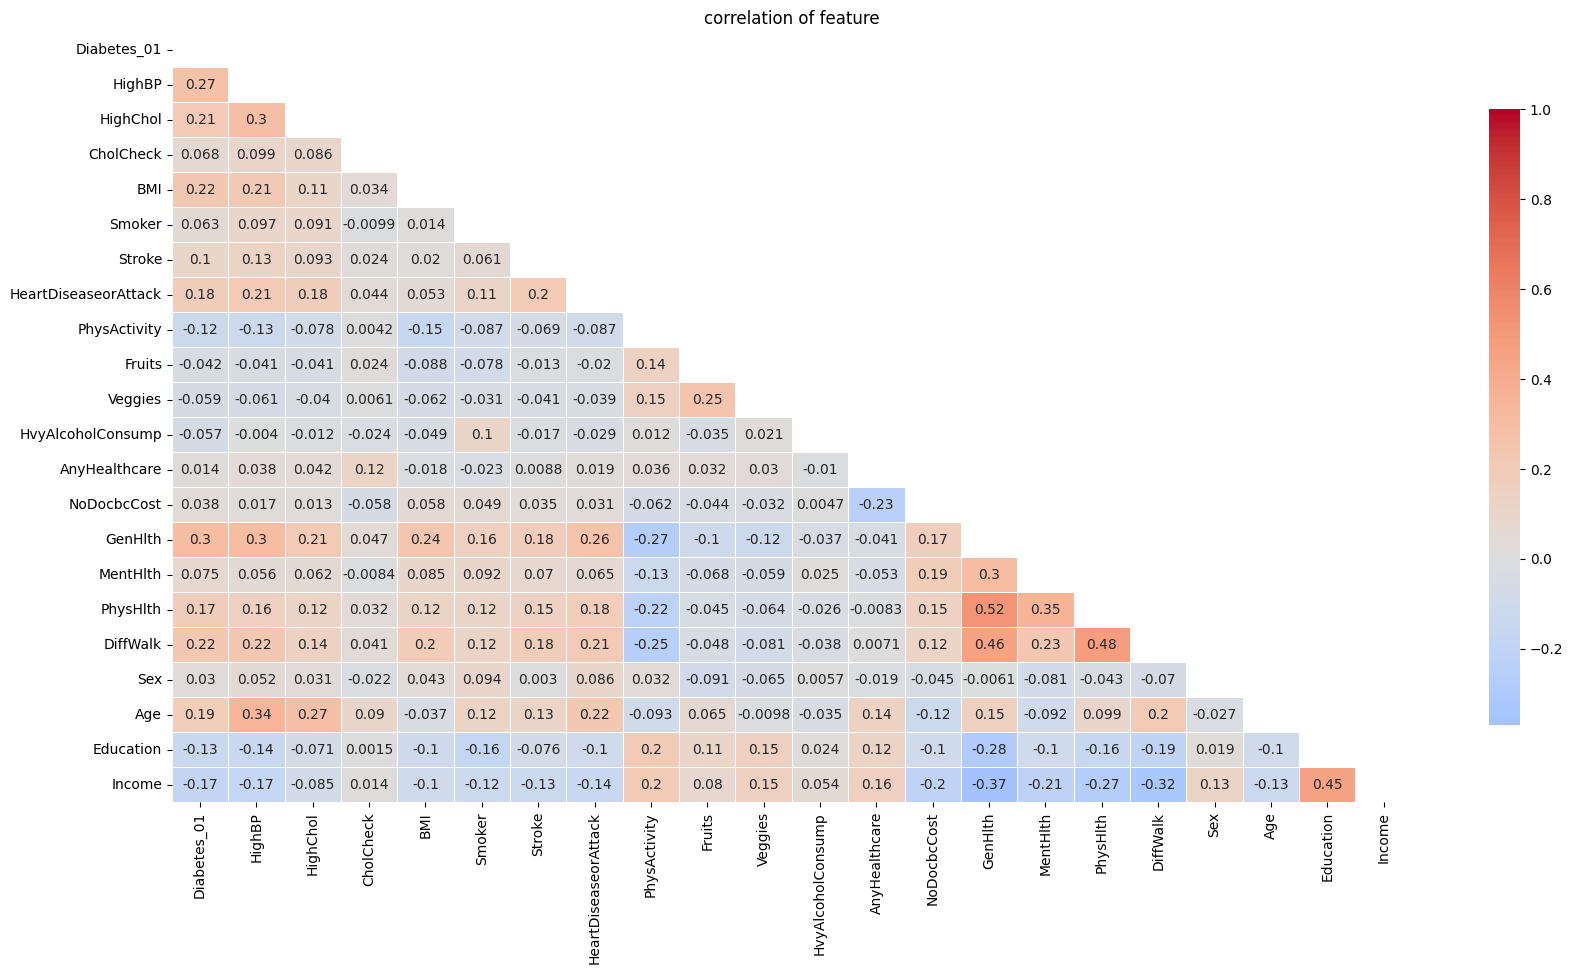

In [49]:
plt.figure(figsize = (20,10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, cmap='coolwarm', vmax=1, center=0,
             linewidths=.5, cbar_kws={"shrink": 0.8}, annot=True)

plt.title("correlation of feature")

Looking at the heatmap, we can see that there are pairs of variables that have high correlations. There are few pairs with medium correlation for instance:

- `PhysHlth` and `GenHlth`
    
    
- `PhysHlth` and `DiffWalk`

    
- `DiffWalk` and `GenHlth`
    
    
- `Education` and `Income`
    


In [50]:
# 1. Calculate the correlation matrix
corr_matrix = df.corr()

# 2. Unstack the matrix into a Series
corr_pairs = corr_matrix.unstack()

# 3. Filter out self-correlations (where Feature 1 == Feature 2)
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False)

# 4. Remove self-correlations and duplicates (A-B and B-A)
top_10_corr = sorted_pairs[sorted_pairs < 1.0].drop_duplicates().head(10)

print(top_10_corr)

GenHlth    PhysHlth       0.524364
DiffWalk   PhysHlth       0.478417
GenHlth    DiffWalk       0.456920
Education  Income         0.449106
PhysHlth   MentHlth       0.353619
Age        HighBP         0.344452
MentHlth   GenHlth        0.301674
GenHlth    Diabetes_01    0.300785
           HighBP         0.300530
HighBP     HighChol       0.298199
dtype: float64


We can make several observations based on the correlation between the variables: 
1. Income levels rise with educational attainment.
2. Blood pressure tends to increase as people age.
3. High blood pressure and high cholesterol often occur together
4. Poor mental health is linked to poor physical health.

### Features Impacting Diabetes ### 

<Axes: >

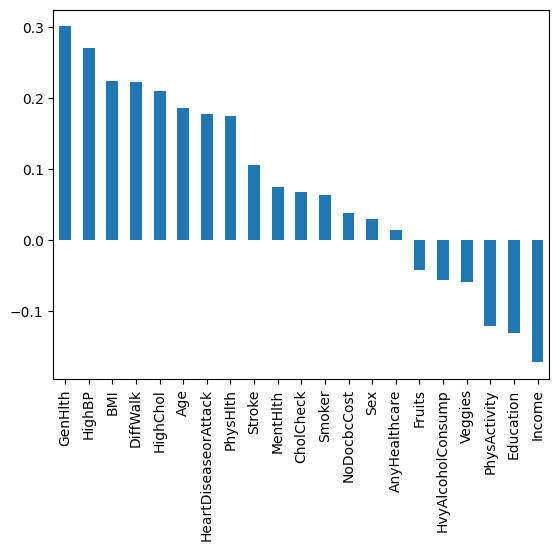

In [51]:
df.corr()['Diabetes_01'].sort_values(ascending=False)[1:].plot.bar()

In [52]:
df.corr()['Diabetes_01'].sort_values(ascending=False).round(3)

Diabetes_01             1.000
GenHlth                 0.301
HighBP                  0.270
BMI                     0.224
DiffWalk                0.222
HighChol                0.210
Age                     0.186
HeartDiseaseorAttack    0.177
PhysHlth                0.175
Stroke                  0.105
MentHlth                0.075
CholCheck               0.068
Smoker                  0.063
NoDocbcCost             0.038
Sex                     0.030
AnyHealthcare           0.014
Fruits                 -0.042
HvyAlcoholConsump      -0.057
Veggies                -0.059
PhysActivity           -0.121
Education              -0.132
Income                 -0.173
Name: Diabetes_01, dtype: float64

**Visualise the cases of diabetes vs non-diabetes for each feature**

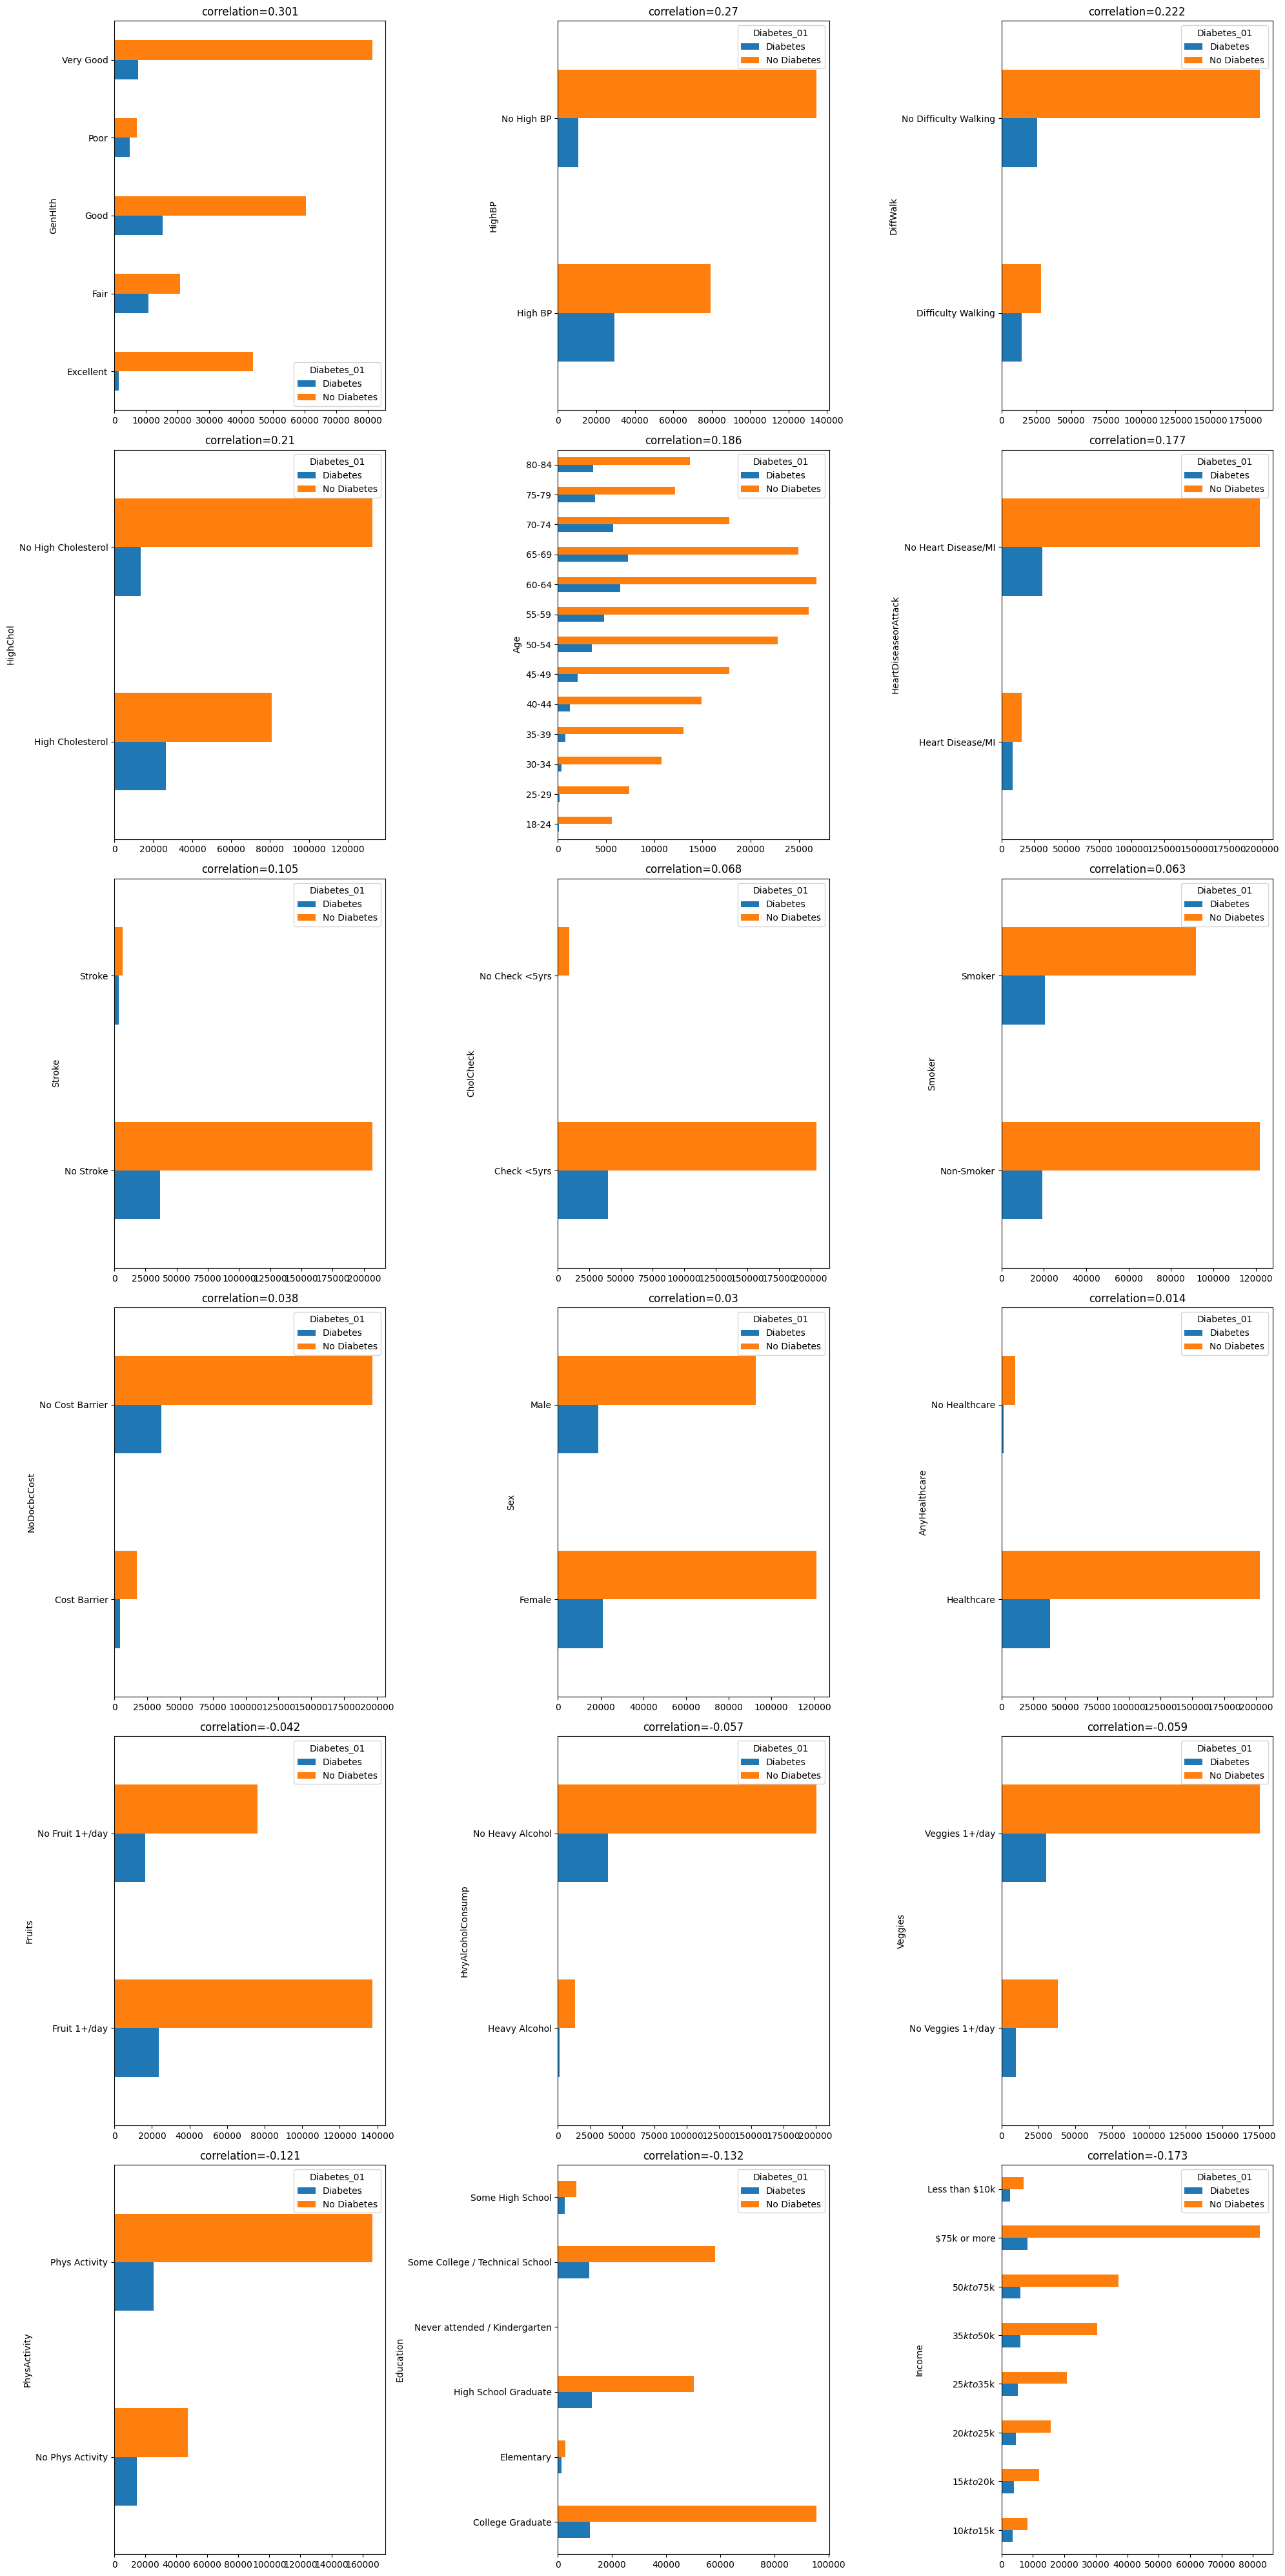

In [53]:
fig, ax = plt.subplots(6, 3, figsize=(20,40))
axe = ax.ravel()
columns = df.corr()['Diabetes_01'].sort_values(ascending=False)[1:].index
values = df.corr()['Diabetes_01'].sort_values(ascending=False)[1:].values
# get features with unique values < 15 
cols = df.columns[df.nunique() < 15][1:]
columns_ = df.corr()['Diabetes_01'].sort_values(ascending=False)[1:][columns.isin(cols)].index
values_ = df.corr()['Diabetes_01'].sort_values(ascending=False)[1:][columns.isin(cols)].values

for i,col in enumerate(  columns_ ):
    data = df_label.groupby([col, 'Diabetes_01']).size().reset_index().pivot(columns='Diabetes_01', index=col, values=0) \
        .plot.barh(ax=axe[i], title = f'correlation={values_[i].round(3)}')
plt.tight_layout()
plt.show()

The visual analysis above allows us to filter features based on their predictive potential. Several variables—including __CholCheck__, __Stroke__, __Heavy Alcohol Consumption__, __AnyHealthcare__, __CostBarrier__—exhibit significant response skewness. 

Due to this lack of variance, these features provide limited explanatory power and will be excluded from the model training phase to improve performance.



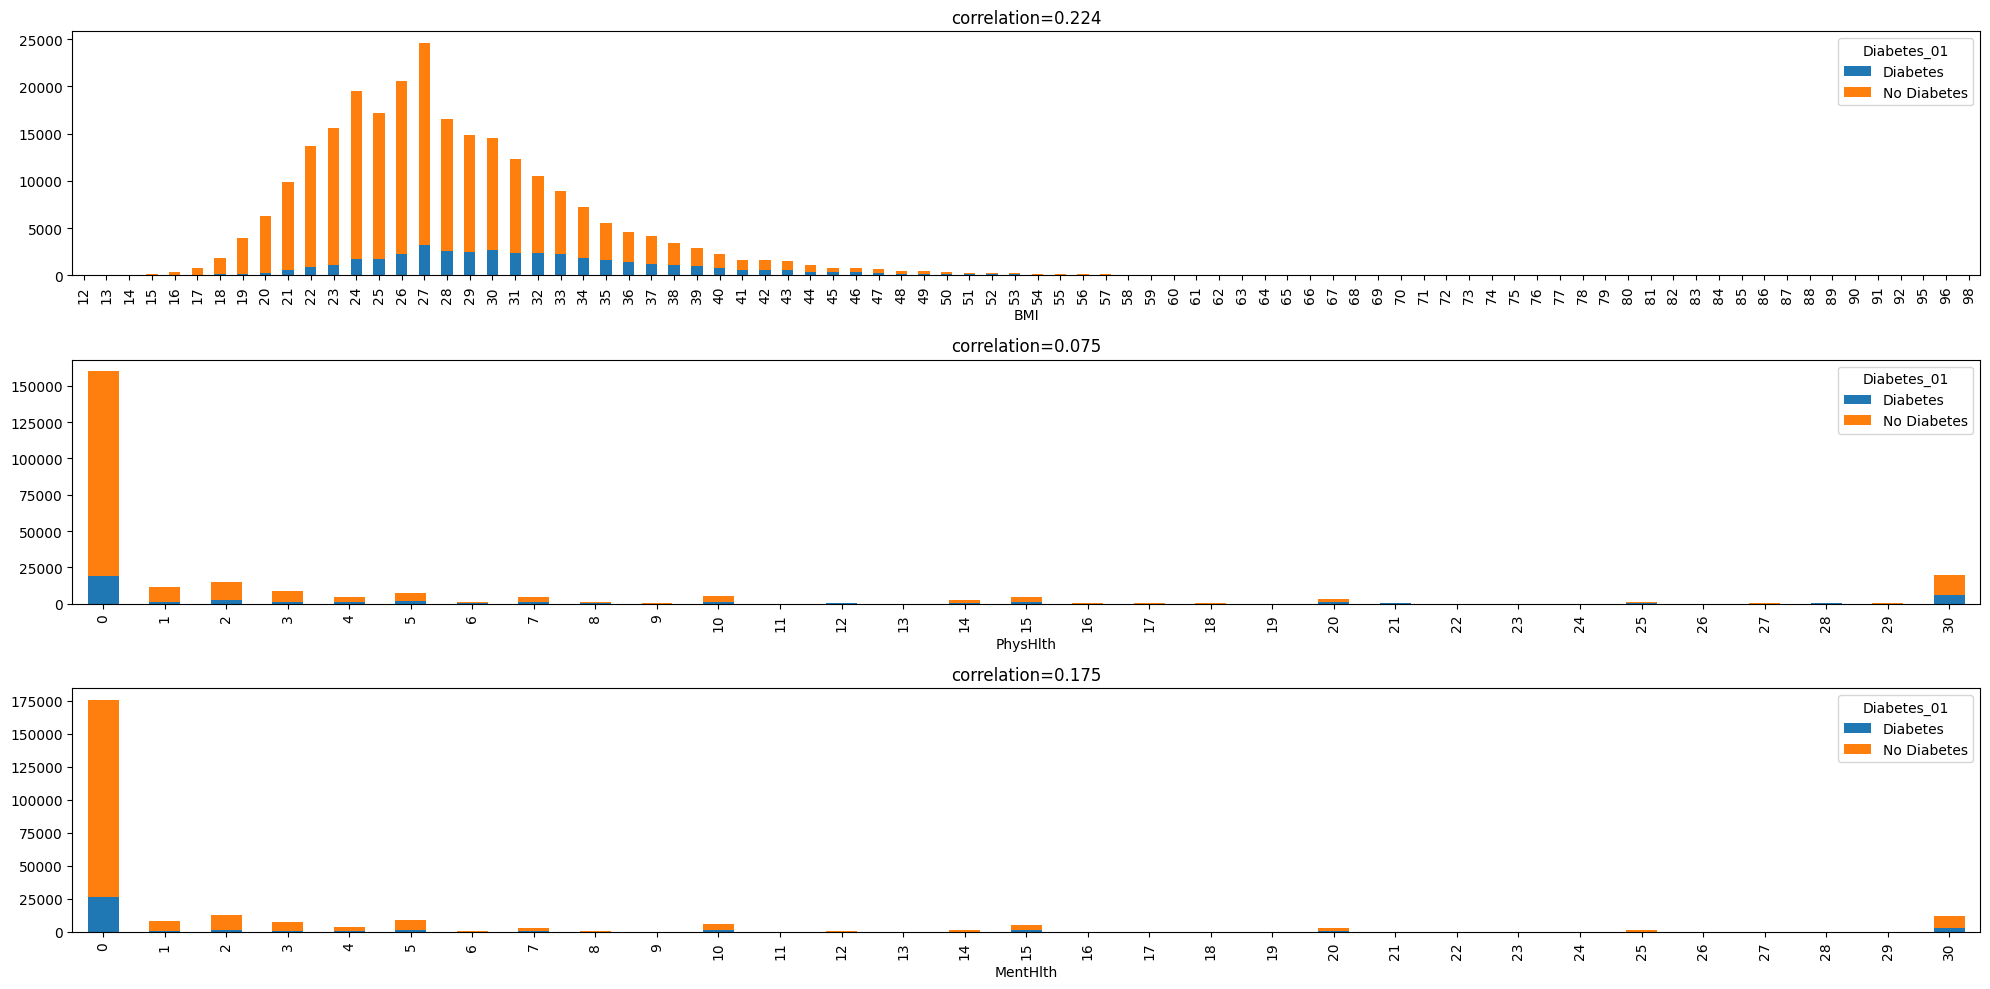

In [54]:
# Plot features with high categorical values

fig, ax = plt.subplots(3, 1, figsize=(20,10))
axe = ax.ravel()
columns = ['BMI', 'PhysHlth', 'MentHlth']
values = df.corr()['Diabetes_01'][ df.corr()['Diabetes_01'].index.isin(['BMI', 'PhysHlth', 'MentHlth'])].values

for i,col in enumerate(  columns ):
    data = df_label.groupby([col, 'Diabetes_01']).size().reset_index().pivot(columns='Diabetes_01', index=col, values=0) \
      .plot.bar(ax=axe[i], stacked=True, title=f'correlation={values[i].round(3)}')
plt.tight_layout()
plt.show()

There are relatively low number of responses for groups with days more than 10 to 29 days, so we can group these responses to reduce the data skewness.

<Axes: xlabel='MentHlth'>

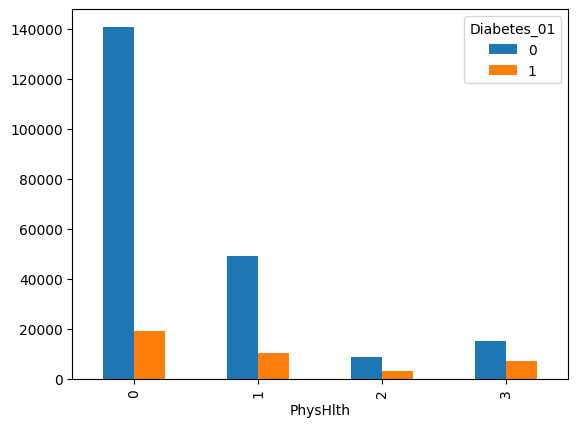

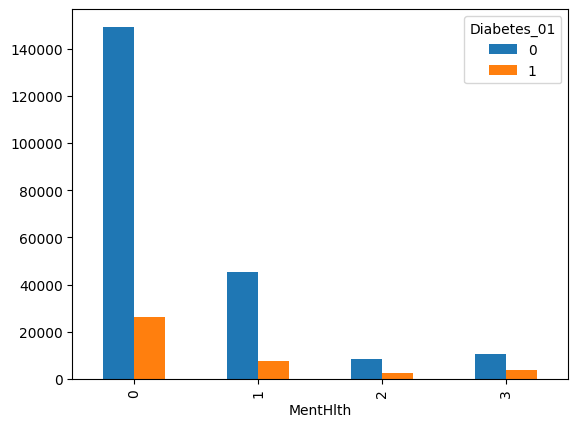

In [55]:
# assign clean copy 
dfc = df.copy()

bins = [-1, 0, 10, 20, 30]
labels = [0, 1, 2, 3]

dfc['PhysHlth'] = pd.cut(dfc['PhysHlth'], bins=bins, labels=labels).astype(int)
dfc['MentHlth'] = pd.cut(dfc['MentHlth'], bins=bins, labels=labels).astype(int)

dfc.groupby(['PhysHlth', 'Diabetes_01']).size().reset_index().pivot(columns='Diabetes_01', index='PhysHlth', values=0) \
      .plot.bar()
dfc.groupby(['MentHlth', 'Diabetes_01']).size().reset_index().pivot(columns='Diabetes_01', index='MentHlth', values=0) \
      .plot.bar()


## Feature Engineering ##

### Data Scaling ###

Before training the model, we need to scale the data to prevent features with large magnitudes (e.g., `BMI`) from dominating those with small magnitudes during machine learning model training. It ensures all features contribute equally to calculations, accelerates convergence in gradient-based algorithms. 

We will apply the __RobustScaler__ scaling method to reduce the impact of outliers by scaling data using median and interquartile range (IQR) which makes it fit to extreme values. We use it when our data contains many outliers and we need to maintain relative distances between non-outlier data points or we’re working with algorithms which are sensitive to extreme values.

C:\Users\yam__\AppData\Local\Temp\ipykernel_48852\1285216601.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\yam__\AppData\Local\Temp\ipykernel_48852\1285216601.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


Text(0, 0.5, 'Standardized Score (Z-Score)')

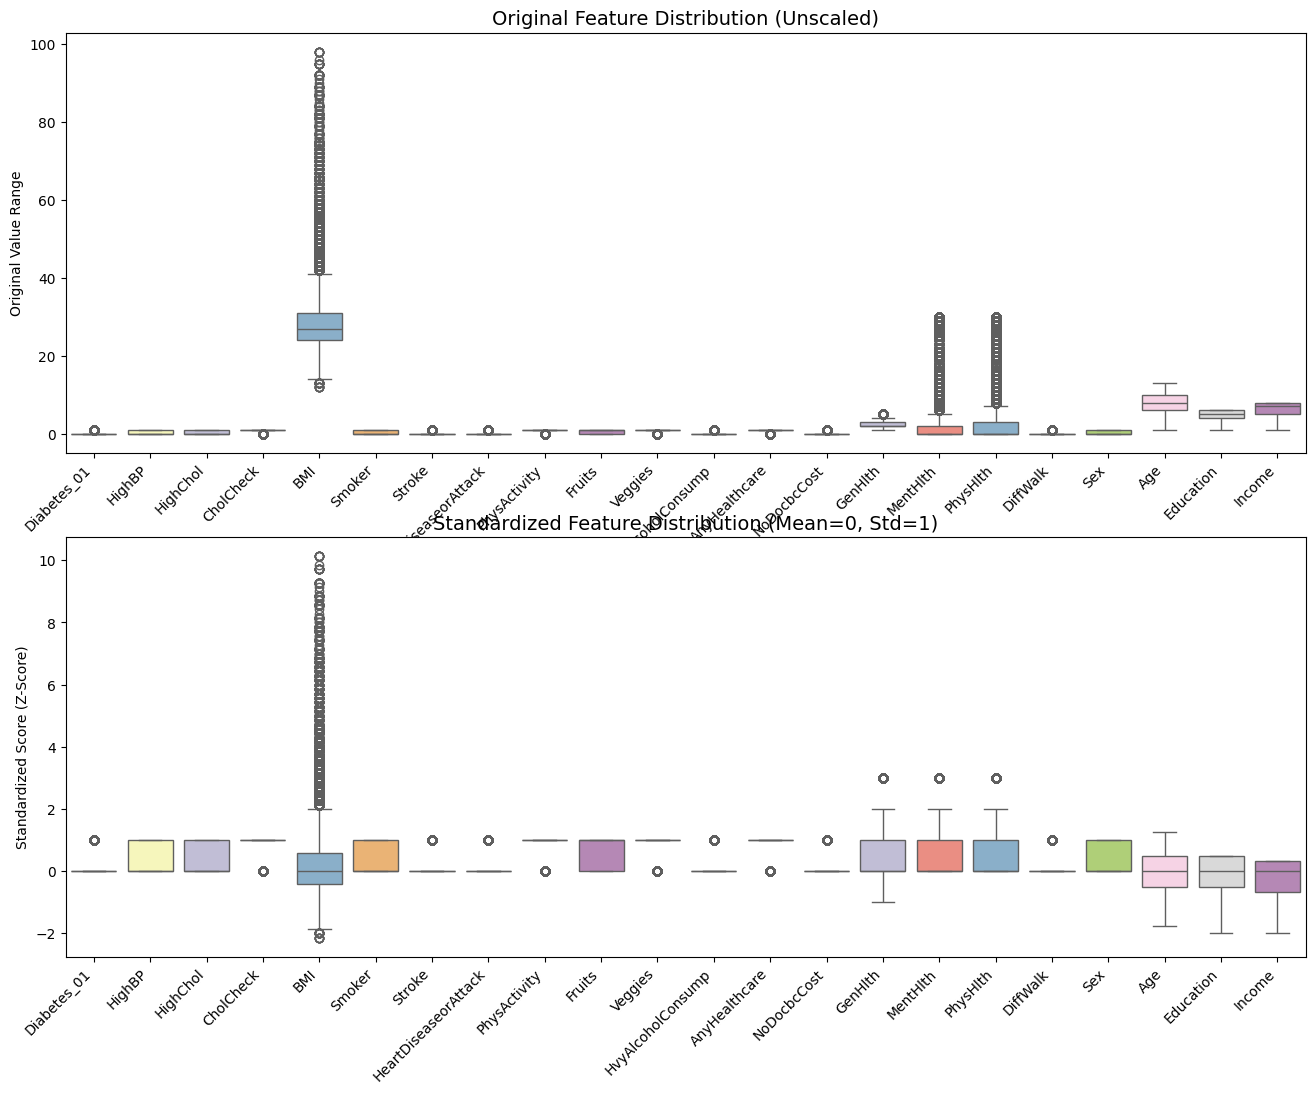

In [56]:
# Initialize the scaler
scaler=RobustScaler()
#scaler = make_pipeline(RobustScaler(), MinMaxScaler())
#scaler = QuantileTransformer(output_distribution='normal')

# Get columns to scale
columns_to_scale = df.columns[df.nunique() > 2]

# Copy the cleaned dataset
dfc_scaled = dfc.copy()

# Applying the scaler to the necessary columns in the dataset
dfc_scaled[columns_to_scale] = scaler.fit_transform(dfc_scaled[columns_to_scale])

# Display the first few rows of the scaled data
#dfc_scaled.describe()

# 3. Create Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot Original Data
sns.boxplot(data=df, ax=ax1, palette='Set3')
ax1.set_title('Original Feature Distribution (Unscaled)', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Original Value Range')

# Plot Scaled Data
sns.boxplot(data=dfc_scaled, ax=ax2, palette='Set3')
ax2.set_title('Standardized Feature Distribution (Mean=0, Std=1)', fontsize=14)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylabel('Standardized Score (Z-Score)')

### Feature Selection ###

We will use chi square test to select the importance feature for model training. 

Using the Chi-Square ($\chi^2$) test for feature selection is a great way to filter out noise, especially when dealing with categorical features.In machine learning, this is a type of Filter Method. It calculates the independence between each feature and the target variable. 

If a feature is independent of the target, it is considered "unimportant" and dropped.

<Axes: >

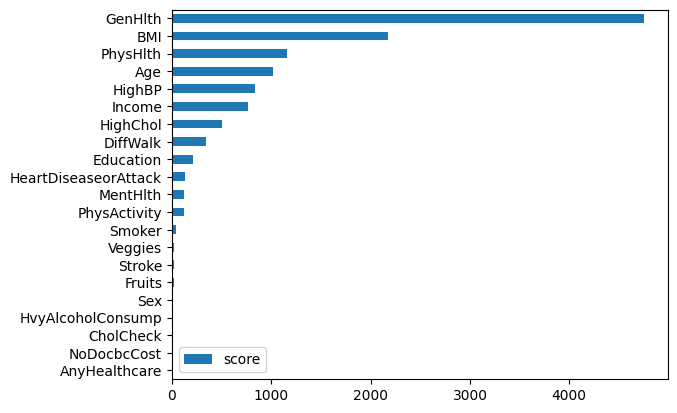

In [57]:
# Assign feature and target data
X=dfc_scaled.drop(columns='Diabetes_01') + 5
Y=dfc_scaled['Diabetes_01']

# The Chi-Square Test determines whether there is an association between categorical variables 
BestF = SelectKBest(score_func=chi2, k=10).fit(X,Y)
res_c2 = pd.DataFrame(BestF.scores_,X.columns, columns=['score'])
res_c2.sort_values(by='score',ascending=True).plot.barh()

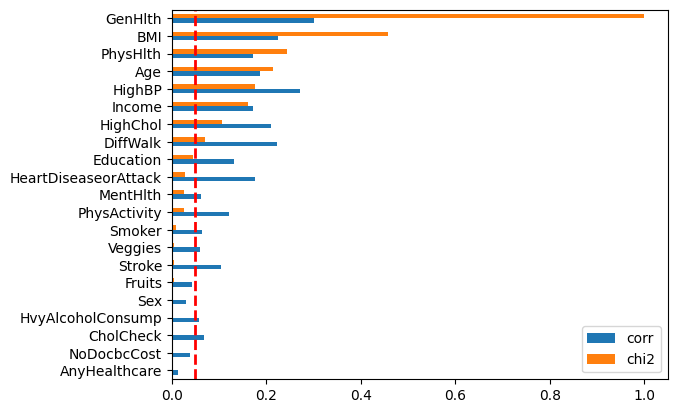

In [58]:
# Let scale the chi2 result and compare with Pearson correlation
minmaxscaler = MinMaxScaler()

res_c2_scaled = pd.DataFrame(
    minmaxscaler.fit_transform(res_c2), 
    index=res_c2.index, 
    columns=res_c2.columns
)

corr = dfc_scaled.corr()['Diabetes_01'][1:]
result = pd.merge(np.abs(corr), res_c2_scaled, left_index=True, right_index=True, how='left')
result.columns=['corr','chi2']
ax =result.sort_values(by='chi2',ascending=True).plot.barh()
# Add the red vertical line at 0.05
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Threshold (0.05)')

Although both concepts are fundamentally different, the result shows that high correlation generally have higher chi2 score.  

We will use chi2 result to filter out the features that does not provide value to the model training (features that has `chi2_scaled` less than 0.05)



In [59]:
# get filtered columns name
columns_reduced  = res_c2_scaled[res_c2_scaled['score'] > 0.05].index

## Model Training ##

We will use some of the popular classifiers to train on the diabetes data. 
1. __Logistic Regression__. It predicts the probability of a sample belonging to a class using a logistic function.
2. __Random Forest (RF))__. An ensemble method that builds multiple decision trees and merges their results (bagging) to get a more accurate and stable prediction.
3. __Support Vector Machine (SVM)__.SVM finds the "hyperplane" that best separates the classes by maximizing the margin between the closest points of different classes (support vectors).
4. __K-Nearest Neighbors (KNN)__ .A "lazy learner" that doesn't really build a model; instead, it stores the training data and classifies new points based on the majority vote of its $k$ closest neighbors.
5. __Gradient Boosting__
Another ensemble method, but unlike Random Forest, it builds trees sequentially. Each new tree attempts to correct the errors made by the previous trees.

In [ ]:

# Define Models and Hyperparameters
model_params = {
    'svm': {
        'model': SGDClassifier(max_iter=5000, tol=1e-3, random_state=42),
        'params': {
            'classifier__loss': ['hinge', 'log_loss', 'modified_huber'],
            'classifier__penalty': ['l2', 'l1', 'elasticnet'],
            'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
        #    'classifier__learning_rate': ['constant', 'optimal', 'adaptive'],
        #    'classifier__eta0': [0.01, 0.1] # Only used if learning_rate is 'constant' or 'adaptive'
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(max_iter=10000),
        'params': {
            'classifier__C': [0.1, 1, 10]
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [5, 10]
        }
    },
    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 10]
        }
    },
    'gradient_boosting': {
        'model': GradientBoostingClassifier(),
        'params': {
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [5, 10]
        }
    }
}

**Imbalanced dataset**

We will apply SMOTE to handle the class imbalance. SMOTE (Synthetic Minority Over-sampling Technique): creates synthetic examples by interpolating between existing minority points.


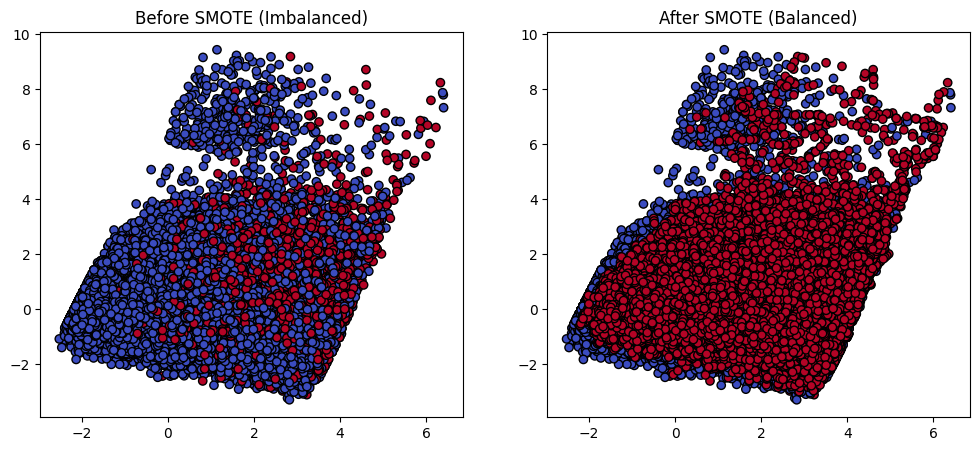

In [61]:
# Assign feature and target
X=dfc_scaled[columns_reduced]
y=dfc_scaled['Diabetes_01']

# Training/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and apply SMOTE only to training data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

# Show result
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_resampled_pca = pca.transform(X_resampled)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_resampled_pca = pca.transform(X_resampled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
ax1.set_title("Before SMOTE (Imbalanced)")

ax2.scatter(X_resampled_pca[:, 0], X_resampled_pca[:, 1], c=y_resampled, cmap='coolwarm', edgecolors='k')
ax2.set_title("After SMOTE (Balanced)")

plt.show()

**Cross-Validation (CV)**

We use Cross-Validation to ensure the model isn't just getting "lucky" with a specific split.The training data is split into $k$ smaller "folds."The model trains on $k-1$ folds and validates on the remaining fold.This repeats $k$ times, and the scores are averaged. This provides a more stable and reliable measure of model performance.

**Hyperparameter Optimization**

We then apply Grid Search to exhaustively tries every possible combination of provided parameters.Randomized Search: Samples a fixed number of combinations from a distribution, which is much faster for large search spaces.

In [62]:
# Cross-Validation & Hyperparameter Tuning Loop
scores = []
best_estimators = {}

print(f"Starting Model Optimization at {datetime.datetime.now().strftime('%H:%M:%S')}\n")
print(f"{'Model':<20} | {'Best F1':<10} | {'Best Parameters'}")
print("-" * 80)

for model_name, mp in model_params.items():
    # 1. Log current model start
    # print(f"Training {model_name}...") 
    
    clf_pipeline = Pipeline([
        ('classifier', mp['model'])
    ])
    
    # 2. Run GridSearchCV
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_resampled, y_resampled)
    
    # 3. Capture Results
    current_best_score = grid.best_score_
    current_best_params = grid.best_params_
    
    scores.append({
        'model': model_name,
        'best_score': current_best_score,
        'best_params': current_best_params
    })
    best_estimators[model_name] = grid.best_estimator_

    # 4. Report Progress Inline
    # Formats: Name (20 chars), Score (fixed 4 decimals), Params string
    print(f"{model_name:<20} | {current_best_score:.4f}     | {current_best_params}")

print("-" * 80)
print(f"Optimization Completed at {datetime.datetime.now().strftime('%H:%M:%S')}")

Starting Model Optimization at 09:14:54

Model                | Best F1    | Best Parameters
--------------------------------------------------------------------------------
svm                  | 0.7536     | {'classifier__alpha': 0.001, 'classifier__loss': 'hinge', 'classifier__penalty': 'l2'}
logistic_regression  | 0.7457     | {'classifier__C': 10}
random_forest        | 0.7906     | {'classifier__max_depth': 10, 'classifier__n_estimators': 50}
knn                  | 0.7719     | {'classifier__n_neighbors': 3}
gradient_boosting    | 0.8097     | {'classifier__n_estimators': 100}
--------------------------------------------------------------------------------
Optimization Completed at 09:20:18


### Results ###

In [63]:
# Model Rankings
df_results = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df_results.sort_values(by='best_score', ascending=False)

,model,best_score,best_params
4,gradient_boosting,0.809662,{'classifier__n_estimators': 100}
2,random_forest,0.790643,"{'classifier__max_depth': 10, 'classifier__n_e..."
3,knn,0.771927,{'classifier__n_neighbors': 3}
0,svm,0.753593,"{'classifier__alpha': 0.001, 'classifier__loss..."
1,logistic_regression,0.745718,{'classifier__C': 10}


In [64]:
# Final Evaluation (Example: Testing the top model)
best_overall_model = best_estimators['gradient_boosting'] 
test_accuracy = best_overall_model.score(X_test, y_test)
print(f"\nFinal Accuracy on Test Set: {test_accuracy:.4f}")


Final Accuracy on Test Set: 0.7636


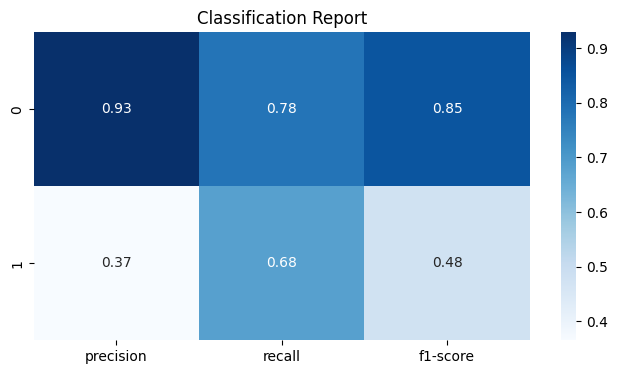

In [ ]:
# Display detailed classification metrics
def plot_classification_report(y_true, y_pred, title='Classification Report'):
    report = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report).iloc[:-1, :-3].T  # Remove support for better scaling
    
    plt.figure(figsize=(8, 4))
    sns.heatmap(df[['precision', 'recall', 'f1-score']], annot=True, cmap='Blues', fmt='.2f')
    plt.title(title)
    plt.show()

# Generate predictions on the test set
y_pred = best_overall_model.predict(X_test)

plot_classification_report(y_test, y_pred)

In [66]:
classification_report(y_test, y_pred, output_dict=True)

{'0': {'precision': 0.9287228109313999,
  'recall': 0.7792049788259516,
  'f1-score': 0.8474192440299742,
  'support': 42741.0},
 '1': {'precision': 0.36562247916106483,
  'recall': 0.6803001876172607,
  'f1-score': 0.47562415285733023,
  'support': 7995.0},
 'accuracy': 0.7636195206559445,
 'macro avg': {'precision': 0.6471726450462323,
  'recall': 0.7297525832216062,
  'f1-score': 0.6615216984436522,
  'support': 50736.0},
 'weighted avg': {'precision': 0.839989226247865,
  'recall': 0.7636195206559445,
  'f1-score': 0.7888316187949282,
  'support': 50736.0}}

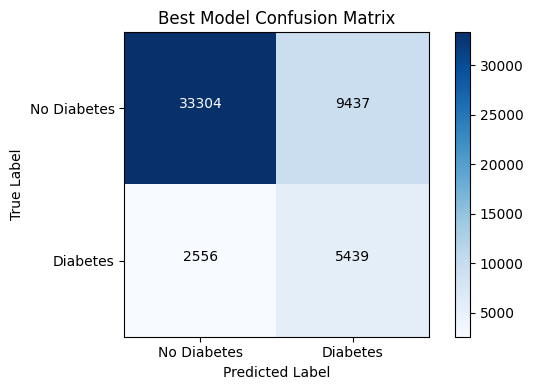

In [67]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# #added during screencast
# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Best Model Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Diabetes', 'Diabetes'])
plt.yticks(tick_marks, ['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations to the confusion matrix
thresh = conf_matrix.max() / 2
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

### Feature Importance ###

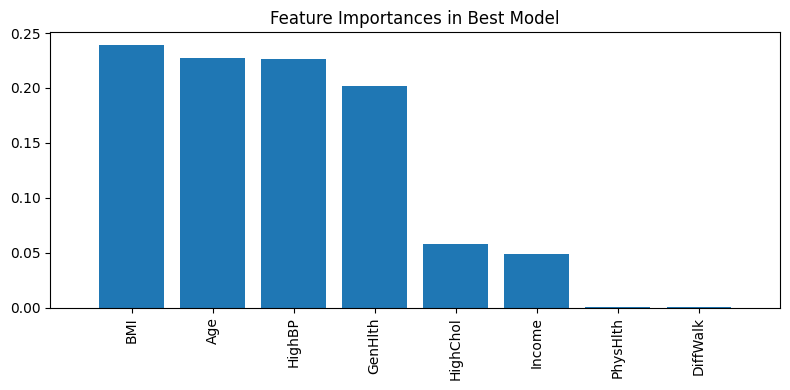


Top 5 most important features:
1. BMI: 0.2387
2. Age: 0.2272
3. HighBP: 0.2261
4. GenHlth: 0.2014
5. HighChol: 0.0575


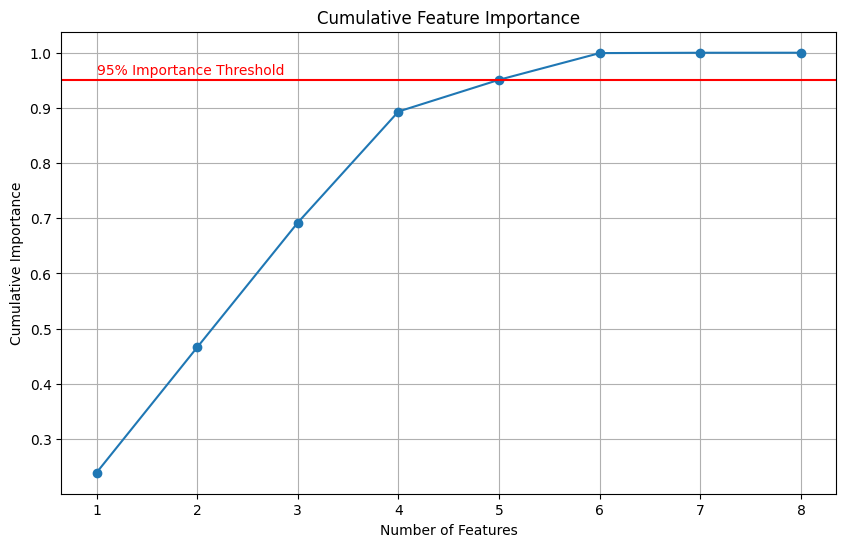


Number of features needed for 95% importance: 5 out of 8


In [68]:
# Extract feature importances from the forest
feature_importances = best_overall_model.steps[0][1].feature_importances_

# Sort features by importance
indices = np.argsort(feature_importances)[::-1]
names = [X.columns[i] for i in indices]

# Create a bar plot of feature importances
plt.figure(figsize=(8, 4))
plt.title("Feature Importances in Best Model", fontsize=12)
plt.bar(range(X.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X.shape[1]), names, rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

# Print the top 5 most important features
print("\nTop 5 most important features:")
for i in range(min(5, len(names))):
    print(f"{i+1}. {names[i]}: {feature_importances[indices[i]]:.4f}")

# We can also look at the cumulative importance
cumulative_importance = np.cumsum(feature_importances[indices])
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Importance Threshold', color='red')
plt.grid(True)
plt.show()

# Find how many features needed for 95% of importance
n_features_95 = np.where(cumulative_importance >= 0.95)[0][0] + 1
print(f"\nNumber of features needed for 95% importance: {n_features_95} out of {len(names)}")
# #added during screencast

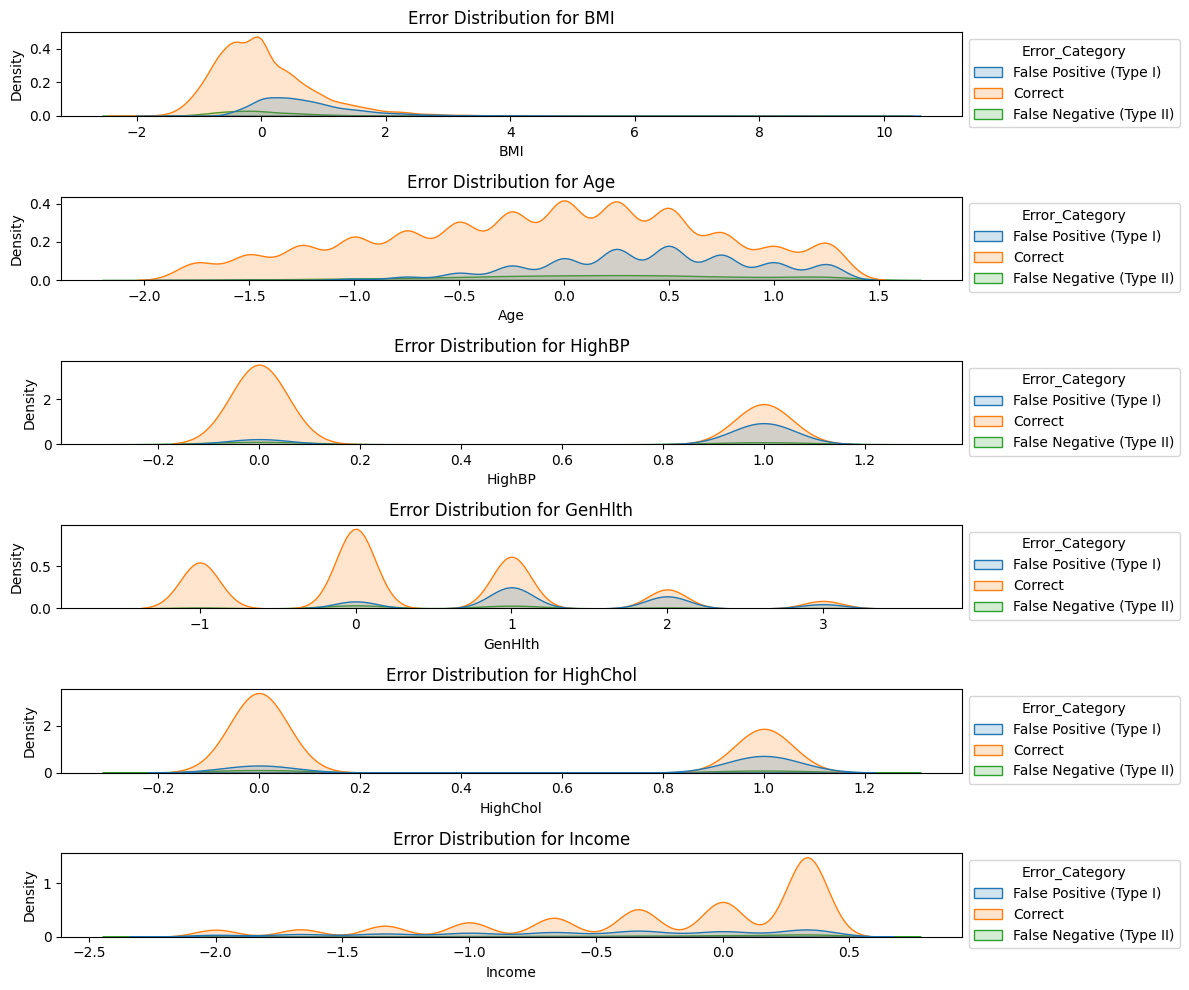

In [100]:
# Assuming 'best_model' is your final trained model and X_test, y_test are available
y_pred = best_overall_model.predict(X_test)

# Identify Error Types
results_df = pd.DataFrame(X_test, columns=X_test.columns)
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

results_df['Analysis'] = 'Correct'
results_df.loc[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0), 'Analysis'] = 'False Negative'
results_df.loc[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1), 'Analysis'] = 'False Positive'

# Extract feature importances from the forest
feature_importances = best_overall_model.steps[0][1].feature_importances_
indices = np.argsort(feature_importances)[::-1]
features_to_plot = [X.columns[i] for i in indices][:6]

fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(12, 10))
for i, col in enumerate(features_to_plot):
    # Plot distribution of correct predictions
    sns.kdeplot(data=analysis_df, hue='Error_Category', 
                x=col, fill=True,  ax=axes[i], alpha=0.2, color='gray',common_norm=True, legend=True)
    sns.move_legend(axes[i], "upper left", bbox_to_anchor=(1, 1))
    axes[i].set_title(f'Error Distribution for {col}')

plt.tight_layout()
plt.show()

### Shap Analysis ###

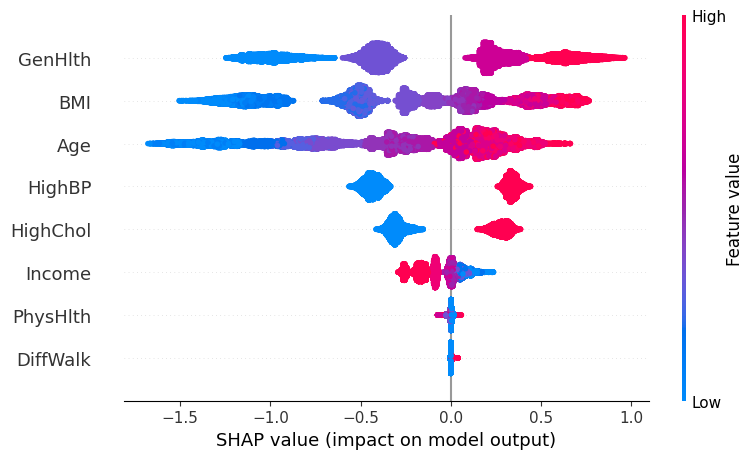

In [ ]:
# Initialize JavaScript for plots 
shap.initjs()

# 1. Create the explainer
model = best_overall_model.named_steps['classifier']
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# 3. Display the summary_plot using SHAP values and testing set.
shap.summary_plot(shap_values, X_test)


1. Y-axis indicates the feature names in order of importance from top to bottom.
2. X-axis represents the SHAP value, which indicates the degree of change in log odds.
3. The color of each point on the graph represents the value of the corresponding feature, with red indicating high values and blue indicating low values.
4. Each point represents a row of data from the original dataset.

If you look at the feature `income`, you will see that it is mostly high with a negative SHAP value. It means higher `income` counts tend to negatively affect the output.

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
shap.force_plot(explainer.expected_value, shap_values[:1000, :], X_test.iloc[:1000, :])

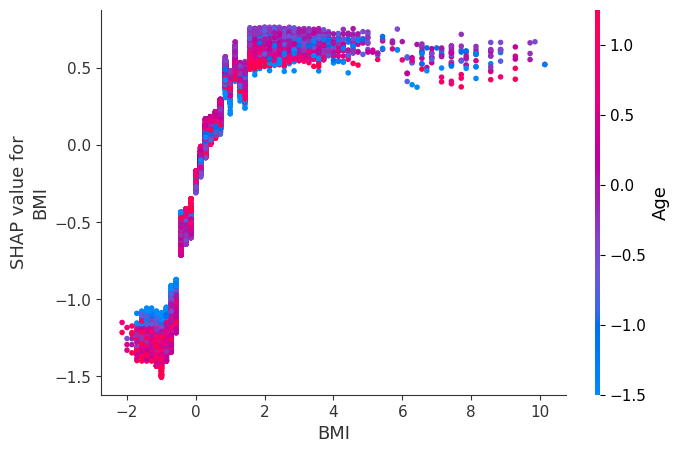

In [ ]:
shap.dependence_plot("BMI", shap_values, X_test,interaction_index="Age")

## Model ReTraining ##

### SMOTE Variant ###

Increasing SMOTE strength can sometimes hurt Precision because you end up creating synthetic points that overlap with the majority class. To fix this, we use a hybrid approach:
1. Oversample heavily (SMOTE).
2. Clean the boundary by removing "ambiguous" points (Tomek Links).

When configuring ADASYN as a "stronger" alternative to SMOTE, keep these differences in mind:

- Targeting: While SMOTE generates a uniform number of samples for each minority point, ADASYN uses a weighted distribution . It generates more samples for points in "noisy" or "hard" regions (low-density minority areas).

- Precision: Because it focuses on difficult areas, it can sometimes introduce noise if the minority samples in those regions are actually outliers rather than representative of a boundary.

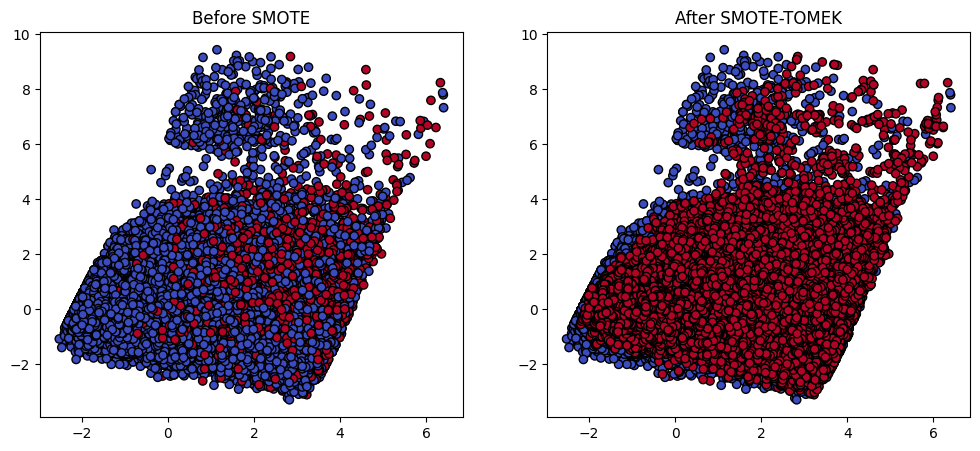

In [105]:
#smote_tomek = SMOTETomek(smote=SMOTE(sampling_strategy=1), random_state=42)
smote_ada = ADASYN(
    sampling_strategy='auto', 
    n_neighbors=7, 
    random_state=42
)

X_resampled, y_resampled = smote_ada.fit_resample(X_train, y_train)

# Show result
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_resampled_pca = pca.transform(X_resampled)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_resampled_pca = pca.transform(X_resampled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
ax1.set_title("Before SMOTE")

ax2.scatter(X_resampled_pca[:, 0], X_resampled_pca[:, 1], c=y_resampled, cmap='coolwarm', edgecolors='k')
ax2.set_title("After SMOTE")

plt.show()

In [106]:
# Cross-Validation & Hyperparameter Tuning Loop
scores = []
best_estimators = {}

print(f"Starting Model Optimization at {datetime.datetime.now().strftime('%H:%M:%S')}\n")
print(f"{'Model':<20} | {'Best F1':<10} | {'Best Parameters'}")
print("-" * 80)

for model_name, mp in model_params.items():
    # 1. Log current model start
    # print(f"Training {model_name}...") 
    
    clf_pipeline = Pipeline([
        ('classifier', mp['model'])
    ])
    
    # 2. Run GridSearchCV
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_resampled, y_resampled)
    
    # 3. Capture Results
    current_best_score = grid.best_score_
    current_best_params = grid.best_params_
    
    scores.append({
        'model': model_name,
        'best_score': current_best_score,
        'best_params': current_best_params
    })
    best_estimators[model_name] = grid.best_estimator_

    # 4. Report Progress Inline
    # Formats: Name (20 chars), Score (fixed 4 decimals), Params string
    print(f"{model_name:<20} | {current_best_score:.4f}     | {current_best_params}")

print("-" * 80)
print(f"Optimization Completed at {datetime.datetime.now().strftime('%H:%M:%S')}")

Starting Model Optimization at 11:28:52

Model                | Best F1    | Best Parameters
--------------------------------------------------------------------------------
svm                  | 0.7370     | {'classifier__alpha': 0.001, 'classifier__loss': 'hinge', 'classifier__penalty': 'l2'}
logistic_regression  | 0.7245     | {'classifier__C': 0.1}
random_forest        | 0.7834     | {'classifier__max_depth': 10, 'classifier__n_estimators': 50}
knn                  | 0.7263     | {'classifier__n_neighbors': 3}
gradient_boosting    | 0.8091     | {'classifier__n_estimators': 100}
--------------------------------------------------------------------------------
Optimization Completed at 11:33:27


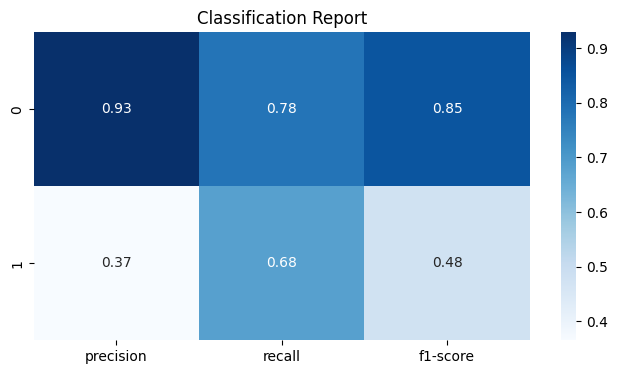

In [107]:
# Generate predictions on the test set
y_pred = best_overall_model.predict(X_test)

plot_classification_report(y_test, y_pred)

### PCA ###

In this step, we are considering the application of dimensionality reduction techniques to simplify our data while retaining the essential information.

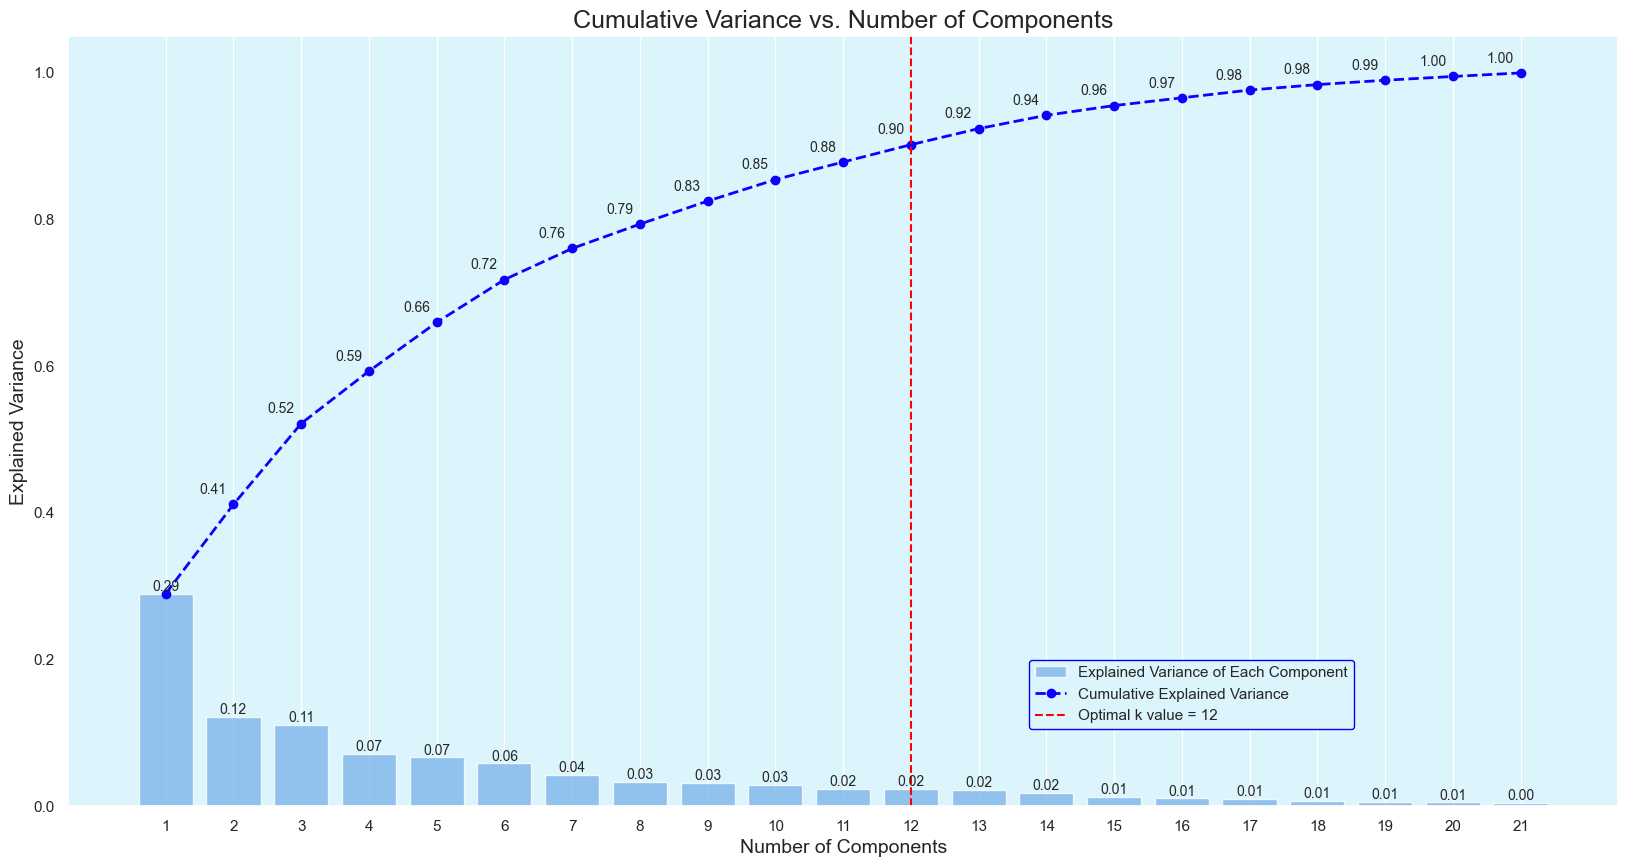

In [113]:
# Assign feature and target
X=dfc_scaled.drop(columns='Diabetes_01')

# Apply PCA
pca = PCA().fit(X)

# Calculate the Cumulative Sum of the Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Set the optimal k value (based on our analysis, we can choose 11)
optimal_k = 12

# Set seaborn plot style
sns.set(rc={'axes.facecolor': "#dcf4fc"}, style='darkgrid')

# Plot the cumulative explained variance against the number of components
plt.figure(figsize=(20, 10))

# Bar chart for the explained variance of each component
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      color="#6db5fc",
                      alpha=0.8)

# Line plot for the cumulative explained variance
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance,
                     marker='o', linestyle='--', color="#0d00ff", linewidth=2)

# Plot optimal k value line
optimal_k_line = plt.axvline(optimal_k - 1, color='red', linestyle='--', label=f'Optimal k value = {optimal_k}') 

# Set labels and title
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

# Customize ticks and legend
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot, optimal_k_line],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance', f'Optimal k value = {optimal_k}'],
           loc=(0.62, 0.1),
           frameon=True,
           framealpha=1.0,  
           edgecolor="#0800ff")  

# Display the variance values for both graphs on the plots
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')   
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #f4f4f3; box-sizing: border-box; font-size:90%; text-align:left">
<h3 align="left"><font color=#ff6200> Comments </font></h3>
    
The plot and the cumulative explained variance values indicate how much of the total variance in the dataset is captured by each principal component, as well as the cumulative variance explained by the first n components.

Here, we can observe that:

- The first component explains approximately 27% of the variance.

- The first two components together explain about 40% of the variance.

- The first three components explain approximately 51% of the variance, and so on.

    
To choose the optimal number of components, we generally look for a point where adding another component doesn't significantly increase the cumulative explained variance, often referred to as the "__elbow point__" in the curve.

From the plot, we can see that the increase in cumulative variance starts to slow down after the __8th component__ (which __captures about 82% of the total variance__).

Considering the context of customer segmentation, we want to retain a sufficient amount of information to identify distinct customer groups effectively. Therefore, retaining __the first 7 components__ might be a balanced choice, as they together explain a substantial portion of the total variance while reducing the dimensionality of the dataset.

In [119]:
# Creating a PCA object with 6 components
pca = PCA(n_components=12)

# Fitting and transforming the original data to the new PCA dataframe
X_pca = pca.fit_transform(X)

# Creating a new dataframe from the PCA dataframe, with columns labeled PC1, PC2, etc.
X_pca = pd.DataFrame(X_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Adding the CustomerID index back to the new PCA dataframe
X_pca.index = X.index

# Displaying the resulting dataframe based on the PCs
X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,3.954030,0.672615,-0.268208,-0.481051,0.462500,0.198249,0.075404,-0.132810,-0.265058,-0.554081,-0.006668,0.033635
1,0.113351,-0.403148,0.137216,-1.600989,-0.755629,-0.811798,0.064144,-0.094594,-0.417685,-0.187582,1.380425,0.222803
2,3.824397,-1.210044,-1.203585,0.749410,0.670330,1.123798,-0.304120,-0.682349,0.006359,-0.084995,-1.190860,-0.160625
3,-0.682202,-0.022300,0.931547,-0.376118,0.369261,-0.346139,-0.597666,-0.018655,-0.085740,0.236944,-0.825947,0.400488
4,-0.391184,-0.611241,0.526109,-0.684862,1.152662,0.055443,-0.604414,-0.235499,0.722739,-0.065216,0.049659,0.147834


In [116]:
# Define a function to highlight the top 3 absolute values in each column of a dataframe
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color:  #ffeacc' if i in top3 else '' for i in column.index]

# Create the PCA component DataFrame and apply the highlighting function
pc_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],  
                     index=X.columns)

pc_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
HighBP,0.128545,0.065134,0.223376,0.007191,0.150825,0.103297,0.100039,-0.092280,0.386005,-0.070963,-0.235526,0.813376
HighChol,0.091208,0.014037,0.171034,0.036119,0.163379,0.151018,0.153559,-0.167201,0.610606,-0.504940,0.046027,-0.474020
CholCheck,0.006758,0.003371,0.019269,0.015771,0.012430,0.014049,-0.011835,-0.010190,0.019796,-0.014558,-0.007728,0.011361
BMI,0.263869,0.930598,-0.045090,0.101659,0.155516,-0.076880,-0.058082,0.061826,-0.073819,0.021606,0.053404,-0.058464
Smoker,0.071763,-0.040347,0.069711,-0.078906,0.044794,0.024197,0.460743,0.656482,-0.282980,-0.452623,0.137828,0.110884
Stroke,0.028331,-0.013755,0.022748,-0.001641,0.009948,0.000017,0.007542,0.000975,0.015207,0.003374,0.003443,0.012778
HeartDiseaseorAttack,0.058041,-0.017074,0.070997,0.006404,0.019141,0.031246,0.051667,0.026033,0.061725,0.023557,0.012104,0.004001
PhysActivity,-0.103348,-0.018787,-0.033468,0.054752,-0.004716,0.067089,-0.114954,0.199377,0.232160,0.092036,0.498577,0.078999
Fruits,-0.045857,-0.044663,0.032711,0.114351,0.061493,0.014292,-0.514213,0.587263,0.286638,0.112879,-0.324777,-0.102715
Veggies,-0.043122,-0.013932,-0.010092,0.098603,0.024468,0.050085,-0.229091,0.297644,0.099871,-0.056834,0.039063,0.030991


In [120]:
smote_ada = ADASYN(
    sampling_strategy='auto', 
    n_neighbors=7, 
    random_state=42
)

# Training/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

X_resampled, y_resampled = smote_ada.fit_resample(X_train, y_train)

In [121]:
# Cross-Validation & Hyperparameter Tuning Loop
scores = []
best_estimators = {}

print(f"Starting Model Optimization at {datetime.datetime.now().strftime('%H:%M:%S')}\n")
print(f"{'Model':<20} | {'Best F1':<10} | {'Best Parameters'}")
print("-" * 80)

for model_name, mp in model_params.items():
    # 1. Log current model start
    # print(f"Training {model_name}...") 
    
    clf_pipeline = Pipeline([
        ('classifier', mp['model'])
    ])
    
    # 2. Run GridSearchCV
    grid = GridSearchCV(clf_pipeline, mp['params'], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_resampled, y_resampled)
    
    # 3. Capture Results
    current_best_score = grid.best_score_
    current_best_params = grid.best_params_
    
    scores.append({
        'model': model_name,
        'best_score': current_best_score,
        'best_params': current_best_params
    })
    best_estimators[model_name] = grid.best_estimator_

    # 4. Report Progress Inline
    # Formats: Name (20 chars), Score (fixed 4 decimals), Params string
    print(f"{model_name:<20} | {current_best_score:.4f}     | {current_best_params}")

print("-" * 80)
print(f"Optimization Completed at {datetime.datetime.now().strftime('%H:%M:%S')}")

Starting Model Optimization at 11:45:00

Model                | Best F1    | Best Parameters
--------------------------------------------------------------------------------
svm                  | 0.7480     | {'classifier__alpha': 0.001, 'classifier__loss': 'hinge', 'classifier__penalty': 'l1'}
logistic_regression  | 0.7376     | {'classifier__C': 0.1}
random_forest        | 0.7673     | {'classifier__max_depth': 10, 'classifier__n_estimators': 100}
knn                  | 0.8386     | {'classifier__n_neighbors': 3}
gradient_boosting    | 0.7561     | {'classifier__n_estimators': 100}
--------------------------------------------------------------------------------
Optimization Completed at 12:09:16


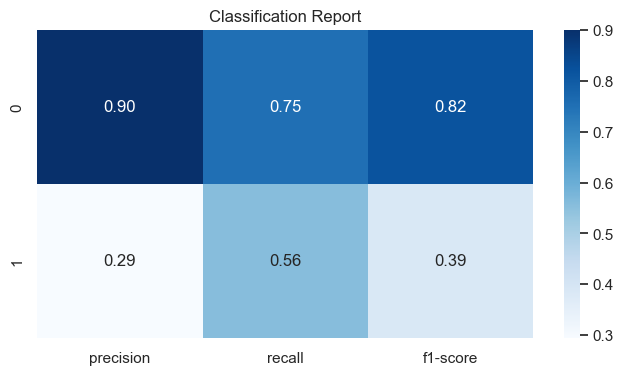

In [123]:
# Generate predictions on the test set
best_overall_model = best_estimators['knn'] 
y_pred = best_overall_model.predict(X_test)
plot_classification_report(y_test, y_pred)

In [126]:
# 1. Define pipeline
pipe = Pipeline([
    ('knn', KNeighborsClassifier())
])

# optimize knn hyperparameter
param_grid = {
    'knn__n_neighbors': list(range(1, 5, 1)), # Odd numbers only
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Perform Grid Search
clf = GridSearchCV( pipe, param_grid, cv=5, scoring='accuracy')
clf.fit(X_resampled, y_resampled)

# 4. Best Parameters
print(f"Best Params: {clf.best_params_}")

Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}


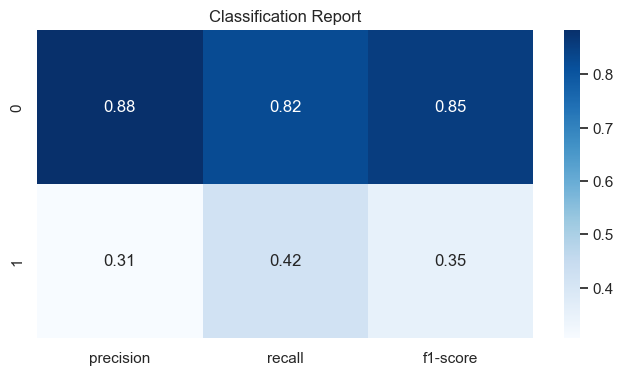

In [128]:
best_knn = clf.best_estimator_
y_pred = best_knn.predict(X_test)
plot_classification_report(y_test, y_pred)